In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Introduction to SegmentTable

**Goal**: Learn how to use `SegmentTable` to manage time-keyed data analysis.

`SegmentTable` is a container for metadata and payload data (like TimeSeries or PSDs) associated with specific time segments. It supports lazy-loading to handle large datasets efficiently.

## 1. Creating a SegmentTable

We'll start by loading sample data from a CSV file. This CSV defines segments with GPS start and end times.

In [1]:
from gwexpy.table import SegmentTable
import os

# Relative path from tutorials directory to docs/_static/samples/
sample_csv = "../../../../_static/samples/sample_segment_data.csv"
st = SegmentTable.read(sample_csv)

print(st)
st.display().head()

   start  end label          span
0      0    4     A    (0.0, 4.0)
1      4    8     B    (4.0, 8.0)
2     10   13     C  (10.0, 13.0)
3     15   20     D  (15.0, 20.0)
4     22   25     E  (22.0, 25.0)


,start,end,label,span
0,0,4,A,"(0.0, 4.0)"
1,4,8,B,"(4.0, 8.0)"
2,10,13,C,"(10.0, 13.0)"
3,15,20,D,"(15.0, 20.0)"
4,22,25,E,"(22.0, 25.0)"


## 2. Visualizing Segments

You can quickly visualize the timeline of your segments.

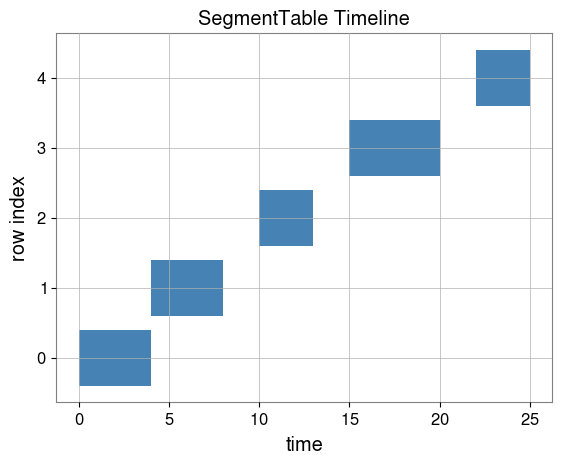

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
st.segments(ax=ax, label="Tutorial Segments")
plt.title("SegmentTable Timeline")
plt.show()

## 3. Lazy Loading Payloads

`SegmentTable` allows you to attach "loaders" to columns. Data is only loaded when actually accessed.

In [3]:
from gwexpy.noise.wave import gaussian

def noise_loader(segment):
    # Generate synthetic noise for the segment
    duration = float(segment[1] - segment[0])
    return gaussian(duration=duration, sample_rate=1024, t0=float(segment[0]))

# Note: Use add_series_column for lazy-loadable payload data (kind='timeseries', etc.)
st.add_series_column("noise", loader=noise_loader, kind="timeseries")

# Accessing the first row's noise (triggers loading)
data_0 = st.row(0)["noise"]
print(f"Loaded {len(data_0)} samples starting at GPS {data_0.t0.value}")

Loaded 4096 samples starting at GPS 0.0


## 4. Processing Rows

You can iterate over rows or use `apply` to process data.

In [4]:
# Calculate RMS for each noise segment
# Use add_column for lightweight metadata results
st.add_column("rms", data=[row["noise"].rms().value for row in st])
st.display()

,start,end,label,span,rms,noise
0,0,4,A,"(0.0, 4.0)",0.998228,<timeseries: 4096 samples>
1,4,8,B,"(4.0, 8.0)",1.003323,<timeseries: 4096 samples>
2,10,13,C,"(10.0, 13.0)",1.001703,<timeseries: 3072 samples>
3,15,20,D,"(15.0, 20.0)",1.010198,<timeseries: 5120 samples>
4,22,25,E,"(22.0, 25.0)",0.998113,<timeseries: 3072 samples>


## 5. Quick Check (NBMAKE)

In [5]:
assert "noise" in st.columns
assert len(st) > 0
print("Validation successful!")

Validation successful!
